# Data Exploration and Cleaning of GSAF Dataset

In [2]:
# Import necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the dataset and view the first 5 rows.
df = pd.read_csv('../data/processed/01_gsaf_tidy_data.csv')
df.head()

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,7070,20th January,2026,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF
1,7069,19th January,2026,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie
2,7068,19th January,2026,Unprovoked,Australia,NSW,North Steyne,Surfing,Andre de Ruyter,M,27,Serious Leg injuries,N,1820hrs,5m shark species not determined,9 News: Bob Myatt GSAF
3,7067,18th January,2026,Unprovoked,Australia,NSW,Nielsen Park Vaucluse Sydney Harbour,Jumping off rocks,Nico Antic,M,12,Serious leg injuries,Y,1620hrs,Bull shark,Bob Myatt GSAF
4,7066,10th January,2026,Unprovoked,Australia,NSW,Avalon Beach,Surfing,Paul Stanton,M,?,Puncture mark to left thumb,N,0540hrs,Unknown,Bob Myatt GSAF


In [4]:
# Inspect the data information, looking for data structure, data types, nulls
df.info()
# Age, time, species has a lot of nulls.
# Many data types that are object that should be string or numeric.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7070 entries, 0 to 7069
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Record_ID  7070 non-null   int64 
 1   Date       7070 non-null   object
 2   Year       7070 non-null   int64 
 3   Type       7053 non-null   object
 4   Country    7020 non-null   object
 5   State      6583 non-null   object
 6   Location   6503 non-null   object
 7   Activity   6485 non-null   object
 8   Name       6851 non-null   object
 9   Sex        6491 non-null   object
 10  Age        4075 non-null   object
 11  Injury     7035 non-null   object
 12  Fatal Y/N  6509 non-null   object
 13  Time       3543 non-null   object
 14  Species    3939 non-null   object
 15  Source     7050 non-null   object
dtypes: int64(2), object(14)
memory usage: 883.9+ KB


In [5]:
# Inspect the column headings.
column_names = df.columns
print(F"\nCOLUMN NAMES:\n\n{column_names}")


COLUMN NAMES:

Index(['Record_ID', 'Date', 'Year', 'Type', 'Country', 'State', 'Location',
       'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time',
       'Species ', 'Source'],
      dtype='object')


In [6]:
# Strip any white spaces from column names.
df.columns = df.columns.str.strip()

In [7]:
# Adjust the name of fatal column. 
df.rename({'Fatal Y/N': 'Fatal'}, axis=1, inplace=True)

In [8]:
# Convert non-numeric object data types to string, all at once.
obj_to_string = ['Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Injury', 'Fatal', 'Source', 'Species']
for col in obj_to_string:
    df[col] = df[col].astype('string')

## Type Column

In [10]:
# Inspect 'Type' column.
print(f"\nUNIQUE VALUES IN 'Type' COLUMN:\n\n{df['Type'].unique()}")


UNIQUE VALUES IN 'Type' COLUMN:

<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'unprovoked',          'Watercraft',        'Sea Disaster',
                  <NA>,                   '?',         'Unconfirmed',
          'Unverified',             'Invalid', 'Under investigation',
                'Boat']
Length: 13, dtype: string


In [11]:
# Capitalize all category entries to create uniformity.
df['Type'] = df['Type'].str.capitalize()

In [12]:
# Boat can be categorized as Watercraft.
df['Type'] = df['Type'].replace(['Boat'], ['Watercraft'])

In [13]:
# Upon examining the data andk it's documentation, nulls and the following types will be categorized as Unknown for this use case. 
replace_data = ['Unconfirmed', 'Unverified', 'Invalid', 'Under investigation', 'Questionable', '?']
replacement = 'Unknown'
df['Type'] = df['Type'].replace(replace_data, replacement).fillna(replacement)

In [14]:
print(f"\nUNIQUE VALUES IN CLEANED 'Type' COLUMN:\n\n{df['Type'].unique()}")


UNIQUE VALUES IN CLEANED 'Type' COLUMN:

<StringArray>
['Unprovoked', 'Provoked', 'Unknown', 'Watercraft', 'Sea disaster']
Length: 5, dtype: string


## Fatal Column

In [16]:
print(f"\nUNIQUE VALUES IN 'Fatal' COLUMN:\n\n{df['Fatal'].unique()}")


UNIQUE VALUES IN 'Fatal' COLUMN:

<StringArray>
['N', 'Y', <NA>, 'n', 'UNKNOWN', 'N ', 'y']
Length: 7, dtype: string


In [17]:
# Remove white spaces and convertt all to upppercase.
df['Fatal']=df['Fatal'].str.strip().str.upper()
# Convert Nulls to UNKNOWN.
df['Fatal'] = df['Fatal'].fillna('UNKNOWN')

In [18]:
print(f"\nUNIQUE VALUES IN CLEANED 'Fatal' COLUMN:\n\n{df['Fatal'].unique()}")


UNIQUE VALUES IN CLEANED 'Fatal' COLUMN:

<StringArray>
['N', 'Y', 'UNKNOWN']
Length: 3, dtype: string


## Age Column

In [20]:
# Inspect the age column.
print(df['Age'].info())
# Look at the age metrics.
df['Age'].describe()

<class 'pandas.core.series.Series'>
RangeIndex: 7070 entries, 0 to 7069
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
4075 non-null   object
dtypes: object(1)
memory usage: 55.4+ KB
None


count     4075
unique     171
top         17
freq       174
Name: Age, dtype: object

In [21]:
# Convert age to numeric data type and any entries that contain non-numeric data to null.
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [22]:
# Create a missing flag for age before filling the nulls to preserve potential for 'unknown age' as an importanat feature.
df['Age_missing']=df['Age'].isna().astype(int)

In [23]:
# Impute 'Age' null with median age.
df['Age'] = df['Age'].fillna(df['Age'].median())

## Sex Column

In [25]:
# Inspect 'Sex' column.
print(f"\nUNIQUE VALUES IN 'Sex' COLUMN:\n\n{df['Sex'].unique()}")


UNIQUE VALUES IN 'Sex' COLUMN:

<StringArray>
['M', 'F', 'F ', 'M ', <NA>, 'm', 'lli', 'N', '.']
Length: 9, dtype: string


In [26]:
# Create uniformity for M and F values.
df['Sex'] = df['Sex'].str.strip().str.upper()

In [27]:
# Inspect unusual entries by creating a list and indexing the DataFrame to select the specific rows.
unusual = ['N', 'LLI', '.']
df_unusual = df.loc[df['Sex'].isin(unusual)]
_ = df_unusual

In [28]:
# Upon inspection, convert the two 'N's and 'LLI' to 'M'.
df['Sex'] = df['Sex'].replace(['N', 'LLI'], 'M')

In [29]:
# Convert remaining values and nulls to UNKNOWN.
df['Sex'] = df['Sex'].replace(['.'],['UNKNOWN']).fillna('UNKNOWN')

In [30]:
print(f"\nUNIQUE VALUES IN CLEANED 'Sex' COLUMN:\n\n{df['Sex'].unique()}")


UNIQUE VALUES IN CLEANED 'Sex' COLUMN:

<StringArray>
['M', 'F', 'UNKNOWN']
Length: 3, dtype: string


## Year Column

In [32]:
# Inspect 'Year' column (df.info() above showed no nulls to deal with).
print(f"\nNumber of unique 'Year' values: {df['Year'].nunique()}") 
print(f"\nUNIQUE VALUES IN 'Year' COLUMN:\n\n{df['Year'].unique().tolist()}")


Number of unique 'Year' values: 261

UNIQUE VALUES IN 'Year' COLUMN:

[2026, 2016, 2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1984, 1994, 1993, 1992, 1991, 1990, 1989, 1969, 1988, 1987, 1986, 1985, 1983, 1982, 1981, 1980, 1979, 1978, 1977, 1976, 1975, 1974, 1973, 1972, 1971, 1970, 1968, 1967, 1966, 1965, 1964, 1963, 1962, 1961, 1960, 1959, 1958, 1957, 1956, 1955, 1954, 1953, 1952, 1951, 1950, 1949, 1948, 1848, 1947, 1946, 1945, 1944, 1943, 1942, 1941, 1940, 1939, 1938, 1937, 1936, 1935, 1934, 1933, 1932, 1931, 1930, 1929, 1928, 1927, 1926, 1925, 1924, 1923, 1922, 1921, 1920, 1919, 1918, 1917, 1916, 1915, 1914, 1913, 1912, 1911, 1910, 1909, 1908, 1907, 1906, 1905, 1904, 1903, 1902, 1901, 1900, 1899, 1898, 1897, 1896, 1895, 1894, 1893, 1892, 1891, 1890, 1889, 1888, 1887, 1886, 1885, 1884, 1883, 1882, 1881, 1880, 1879, 1878, 1877, 1876, 1875, 1874, 1873

In [33]:
# Look entries for very old incidents.
oddity_df = df[df['Year'] <= 77]
_ = oddity_df

In [34]:
# Look at some value counts per year.
year_count = df['Year'].value_counts().head(30).sort_index(ascending=False)
print(year_count.to_string())

Year
2023    109
2022     98
2021    111
2020    101
2019    114
2018    124
2017    142
2016    134
2015    143
2014    126
2013    122
2012    117
2011    128
2010    101
2009    120
2008    122
2007    113
2006    103
2005    103
2004     92
2003     92
2002     88
2001     92
2000     97
1995     76
1962     86
1961     78
1960     93
1959     93
0       129


In [35]:
# Records are very few and sparse before 1900, keep records from 1900 to 2025 for analysis.
df = df[df['Year'].between(1900, 2025)]

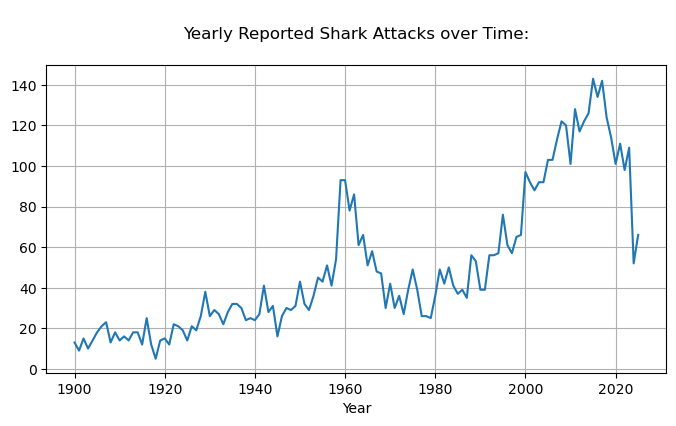

In [36]:
# Look at number of incident reports over time.
yearly_attacks = df.groupby('Year').size()
# Plot the line for visualization.
plt.figure(figsize=(8,4))
yearly_attacks.plot(kind='line', grid=1, title='\nYearly Reported Shark Attacks over Time:\n')
plt.show()

### The 1960 SPIKE: An international shark attack file was created in 1959 to collect data on attacks, contributing to the spike (https://siarchives.si.edu/blog/shark-attack-tracks).

## Country Column

In [39]:
# Inspect the unique country names.
country_names = df['Country'].unique().tolist()
print(f"\nUNIQUE COUNTRIES IN 'Country' COLUMN:\n\n{country_names}")


UNIQUE COUNTRIES IN 'Country' COLUMN:

['Australia', 'USA', 'French Polynesia', 'Samoa', 'Columbia', 'Costa Rica', 'Bahamas', 'Puerto Rico', 'Spain', 'Canary Islands', 'South Africa', 'Vanuatu', 'Jamaica', 'Israel', 'Mexico', 'Maldives', 'Philippines', 'Turks and Caicos', 'Mozambique', 'New Caledonia', 'Egypt', 'Thailand', 'New Zealand', 'Hawaii', 'Honduras', 'Indonesia', 'Morocco', 'Belize', 'Maldive Islands', 'Tobago', 'AUSTRALIA', 'INDIA', 'TRINIDAD', 'BAHAMAS', 'SOUTH AFRICA', 'MEXICO', 'NEW ZEALAND', 'EGYPT', 'BELIZE', 'PHILIPPINES', 'Coral Sea', 'SPAIN', 'PORTUGAL', 'SAMOA', 'COLOMBIA', 'ECUADOR', 'FRENCH POLYNESIA', 'NEW CALEDONIA', 'TURKS and CaICOS', 'CUBA', 'BRAZIL', 'SEYCHELLES', 'ARGENTINA', 'FIJI', 'MeXICO', 'ENGLAND', 'JAPAN', 'INDONESIA', 'JAMAICA', 'MALDIVES', 'THAILAND', 'COLUMBIA', 'COSTA RICA', 'British Overseas Territory', 'CANADA', 'JORDAN', 'ST KITTS / NEVIS', 'ST MARTIN', 'PAPUA NEW GUINEA', 'REUNION ISLAND', 'ISRAEL', 'CHINA', 'IRELAND', 'ITALY', 'MALAYSIA', 'L

In [40]:
# Convert all to uppercase for uniformity.
df['Country'] = df['Country'].str.upper()
# Trim white leading and lagging spaces.
df['Country'] = df['Country'].str.strip()
# Convert Countries followed by '?' to null due to uncertainty.
df['Country'] = df['Country'].replace(r'.*\?.*', np.nan, regex=True)
# Check null count.
print(f"NULL COUNT FOR 'Country' COLUMN: {df['Country'].isnull().sum()}")

NULL COUNT FOR 'Country' COLUMN: 25


In [41]:
# Convert nulls to UNKNOWN so they are not ignored in analysis.
df['Country'] = df['Country'].fillna('UNKNOWN')

In [42]:
# Examine country names that are oceans using boolean mask.
oceans = df['Country'].str.contains('OCEAN', na=False) 
unique_oceans = df.loc[oceans, 'Country'].unique().tolist()
print(f"\nUNIQUE OCEANS:\n{unique_oceans}")


UNIQUE OCEANS:
['ATLANTIC OCEAN', 'NORTH ATLANTIC OCEAN', 'PACIFIC OCEAN', 'SOUTH PACIFIC OCEAN', 'NORTH PACIFIC OCEAN', 'MID ATLANTIC OCEAN', 'SOUTH ATLANTIC OCEAN', 'RED SEA / INDIAN OCEAN', 'INDIAN OCEAN', 'SOUTHWEST PACIFIC OCEAN', 'MID-PACIFC OCEAN']


In [43]:
# Count the number or rows where 'Country' is an ocean.
ocean_count = df.loc[oceans, 'Country'].count()
print(f"\nINCIDENTS REPORTED WITH AN OCEAN IN THE 'Country' COLUMN: {ocean_count}")
# Look at value counts per ocean entry.
per_ocean_count = df.loc[oceans, 'Country'].value_counts()
print(f"\nOcean Value Counts: {per_ocean_count.to_string()}")


INCIDENTS REPORTED WITH AN OCEAN IN THE 'Country' COLUMN: 62

Ocean Value Counts: Country
PACIFIC OCEAN              15
ATLANTIC OCEAN             12
SOUTH ATLANTIC OCEAN        8
NORTH PACIFIC OCEAN         6
NORTH ATLANTIC OCEAN        5
MID ATLANTIC OCEAN          5
INDIAN OCEAN                5
SOUTH PACIFIC OCEAN         2
SOUTHWEST PACIFIC OCEAN     2
RED SEA / INDIAN OCEAN      1
MID-PACIFC OCEAN            1


In [44]:
# Red sea is part of the Indian Ocean, so categorize it as INDIAN OCEAN only.
df['Country'] = df['Country'].replace('RED SEA / INDIAN OCEAN', 'INDIAN OCEAN')
# Replace the "-" with a space in mid-pacific ocean for uniformity.
df['Country'] = df['Country'].replace('MID-PACIFC OCEAN', 'MID PACIFIC OCEAN')

In [45]:
# Examine countries with a "/" in their name.
combos = df['Country'].str.contains(r'/', na=False)
unique_combos = df.loc[combos, 'Country'].unique().tolist()
print("\nUNIQUE 'COMBO' COUNTRIES:")
unique_combos


UNIQUE 'COMBO' COUNTRIES:


['ST KITTS / NEVIS',
 'EGYPT / ISRAEL',
 'ANDAMAN / NICOBAR ISLANDAS',
 'IRAN / IRAQ',
 'SOLOMON ISLANDS / VANUATU',
 'ITALY / CROATIA']

In [46]:
# Look at value counts for the combined countries.
per_combo_count = df.loc[combos, 'Country'].value_counts()
print(F"\nCOMBINED COUNTRIES VALUE COUNTS:{per_combo_count.to_string()}")


COMBINED COUNTRIES VALUE COUNTS:Country
ST KITTS / NEVIS              1
EGYPT / ISRAEL                1
ANDAMAN / NICOBAR ISLANDAS    1
IRAN / IRAQ                   1
SOLOMON ISLANDS / VANUATU     1
ITALY / CROATIA               1


In [47]:
# Examine the combination country rows to help decide how to handle them.
_ = df.loc[combos]

In [48]:
# Adjust the combination names using common sense.
df['Country'] = df['Country'].replace("ST KITTS / NEVIS", "ST KITTS AND NEVIS")
df['Country'] = df['Country'].replace("EGYPT / ISRAEL", "EGYPT")
df['Country'] = df['Country'].replace("ANDAMAN / NICOBAR ISLANDAS", "ANDAMAN AND NICOBAR ISLANDS")
df['Country'] = df['Country'].replace("IRAN / IRAQ", "IRAQ")
df['Country'] = df['Country'].replace("SOLOMON ISLANDS / VANUATU", "SOLOMON ISLANDS")
df['Country'] = df['Country'].replace("ITALY / CROATIA", "CROATIA")

In [49]:
# Make further adjustments for uniformity. 
df['Country'] = df['Country'].replace('UNITED ARAB EMIRATES (UAE)', 'UNITED ARAB EMIRATES')
df['Country'] = df['Country'].replace('ST. MARTIN', 'ST MARTIN')
df['Country'] = df['Country'].str.replace(r'&', 'AND')

In [50]:
print(f"NULL COUNT FOR 'Country': {df['Country'].isnull().sum()}")
# Convert nulls to UNKNOWN so they are not ignored in analysis.
df['Country'] = df['Country'].fillna('Unknown')

NULL COUNT FOR 'Country': 0


In [51]:
# Further inspect the 'Country' column.
print(f"\nNUMBER OF UNIQUE COUNTRIES IN CLEANED 'Country' COLUMN: {df['Country'].nunique()}")


NUMBER OF UNIQUE COUNTRIES IN CLEANED 'Country' COLUMN: 172


In [52]:
# Look at which countries have the most reported shark attacks.
top_countries = df['Country'].value_counts().nlargest(10)#.index
print(f"\nTEN COUNTRIES WITH THE MOST REPORTED SHARK ATTACKS:\n{top_countries.to_string()}")


TEN COUNTRIES WITH THE MOST REPORTED SHARK ATTACKS:
Country
USA                 2427
AUSTRALIA           1356
SOUTH AFRICA         569
BAHAMAS              132
PAPUA NEW GUINEA     132
BRAZIL               118
NEW ZEALAND          115
MEXICO                95
NEW CALEDONIA         64
ITALY                 62


## Species Column

In [54]:
# Inspect 'Species' column.
print(f"\nNUMBER OF UNIQUE SHARK SPECIES: {df['Species'].nunique()}")
print(f"NULL COUNT FOR 'Species': {df['Species'].isnull().sum()}")


NUMBER OF UNIQUE SHARK SPECIES: 1683
NULL COUNT FOR 'Species': 2567


In [55]:
# Inspect a random sample the look at the structure of the 'Species' data.
#df['Species'].unique().tolist()
import random

random.sample(df["Species"].dropna().unique().tolist(), 20)

["Bull shark  6'",
 "8' shark",
 "Bronze whaler shark   3m [10'] ",
 '"sand" shark',
 '3 m  600-kg shark',
 "18' shark",
 '<1 m shark',
 "Possibly a  1.8 m [6'] Zambezi shark",
 'Starry smoothhound shark  1m',
 "2.4 m to 3 m [8' to 10'] white shark",
 'White shark  2 m to 4 m [6\'9" to 13\'] ',
 "4.3 m [14'] shark seen in vicinity",
 'Tiger shark  2.8m',
 'Possibly juvenile tiger shark',
 "2.4 m [8'] shark",
 'A small shark',
 "Possibly a 1.5 m [5'] blacktip shark",
 "Grey reef shark  1.2 m [4'] ",
 "Tiger shark  10' ",
 'Bull shark  1 m']

In [56]:
# Convert to lowercase and fill nulls with 'unknown'.
df['Species'] = df['Species'].str.lower()
df['Species'] = df['Species'].fillna('unknown')

### Clean text data well enough to categorize species using the GSAF website as a guide (https://www.sharkattackfile.net/species.htm). Remaining species will be categorized as 'other'.


In [58]:
# look for great white sharks using a boolean mask and indexing the DataFrame.
whites = df['Species'].str.contains('great white', na=False) 
unique_whites = df.loc[whites, 'Species'].unique().tolist()
print(unique_whites)

['great white shark', 'suspected great white shark', '5m (16.5ft) great white', 'suspected great white', 'great white shark est 3m (10ft)', 'great white', 'great white shart estimated 4.8m 16 ft', 'reportedly a great white', 'great white 6.0m']


In [59]:
# After examining the results for species that don't match, categorize these as 'great white'.
df.loc[whites, 'Species'] = 'great white'

In [60]:
# Fix a couple I just happened to notice.
df['Species'] = df['Species'].replace('wfite shark', 'great white')
df['Species'] = df['Species'].replace('bu.ll', 'bull')

In [61]:
# Repeat the process until species are categorized.
whites2 = df['Species'].str.contains('white shark', na=False)
unique_whites2 = df.loc[whites2, 'Species'].unique().tolist()

# Remaining outputs suppressed for readability, some lists are very long
# print(unique_whites2)

In [62]:
df.loc[whites2, 'Species'] = 'great white'

In [63]:
whites3 = df['Species'].str.contains('oceanic', na=False)
unique_whites3 = df.loc[whites3, 'Species'].unique().tolist()
# print(unique_whites3)

In [64]:
df.loc[whites3, 'Species'] = 'oceanic whitetip'

In [65]:
sandtigers = df['Species'].str.contains('sandtiger', na=False)
unique_sandtigers = df.loc[sandtigers, 'Species'].unique().tolist()
# print(unique_sandtigers)

In [66]:
df.loc[sandtigers, 'Species'] = 'sandtiger'

In [67]:
tigers = df['Species'].str.contains('tiger', na=False)
unique_tigers = df.loc[tigers, 'Species'].unique().tolist()
# print(unique_tigers)

In [68]:
df.loc[tigers, 'Species'] = 'tiger'

In [69]:
lemons = df['Species'].str.contains('lemon', na=False)
unique_lemons = df.loc[lemons, 'Species'].unique().tolist()
# print(unique_lemons)

In [70]:
df.loc[lemons, 'Species'] = 'lemon'

In [71]:
bulls = df['Species'].str.contains('bull', na=False)
unique_bulls = df.loc[bulls, 'Species'].unique().tolist()
# print(unique_bulls)

In [72]:
df.loc[bulls, 'Species'] = 'bull'

In [73]:
makos = df['Species'].str.contains('mako', na=False)
unique_makos = df.loc[makos, 'Species'].unique().tolist()
# print(unique_makos)

In [74]:
df.loc[makos, 'Species'] = 'mako'

In [75]:
makos2 = df['Species'].str.contains('blue pointer', na=False)
unique_makos2 = df.loc[makos2, 'Species'].unique().tolist()
# print(unique_makos2)

In [76]:
df.loc[makos2, 'Species'] = 'mako'

In [77]:
nurse = df['Species'].str.contains('nurse', na=False)
unique_nurse = df.loc[nurse, 'Species'].unique().tolist()
# print(unique_nurse)

In [78]:
df.loc[nurse, 'Species'] = 'nurse'

In [79]:
blackreef = df['Species'].str.contains('black tip reef', na=False) 
unique_blackreef = df.loc[blackreef, 'Species'].unique().tolist()
# print(unique_blackreef)

In [80]:
df.loc[blackreef, 'Species'] = 'blacktip reef'

In [81]:
blackreef2 = df['Species'].str.contains('blacktip reef', na=False) 
unique_blackreef2 = df.loc[blackreef2, 'Species'].unique().tolist()
# print(unique_blackreef2)

In [82]:
df.loc[blackreef2, 'Species'] = 'blacktip reef'

In [83]:
blacktip = df['Species'].str.contains('black tip', na=False)
unique_blacktip = df.loc[blacktip, 'Species'].unique().tolist()
# print(unique_blacktip)

In [84]:
df.loc[blacktip, 'Species'] = 'blacktip'

In [85]:
blacktip2 = df['Species'].str.contains('blacktip', na=False) & (df['Species'] != 'blacktip reef') #exclude blacktip reef from the mask
unique_blacktip2 = df.loc[blacktip2, 'Species'].unique().tolist()
# print(unique_blacktip2)

In [86]:
df.loc[blacktip2, 'Species'] = 'blacktip'

In [87]:
blue = df['Species'].str.contains('blue shark', na=False)
unique_blue = df.loc[blue, 'Species'].unique().tolist()
# print(unique_blue)

In [88]:
df.loc[blue, 'Species'] = 'blue'

In [89]:
whaler = df['Species'].str.contains('whaler', na=False)
unique_whaler = df.loc[whaler, 'Species'].unique().tolist()
# print(unique_whaler)

In [90]:
df.loc[whaler, 'Species'] = 'whaler'

In [91]:
hammer = df['Species'].str.contains('hammer', na=False)
unique_hammer = df.loc[hammer, 'Species'].unique().tolist()
# print(unique_hammer)

In [92]:
df.loc[hammer, 'Species'] = 'hammerhead'

In [93]:
wobbegong = df['Species'].str.contains('wobbegong', na=False)
unique_wobbegong = df.loc[wobbegong, 'Species'].unique().tolist()
# print(unique_wobbegong)

In [94]:
df.loc[wobbegong, 'Species'] = 'wobbegong'

In [95]:
spinner = df['Species'].str.contains('spinner', na=False)
unique_spinner = df.loc[spinner, 'Species'].unique().tolist()
# print(unique_spinner)

In [96]:
df.loc[spinner, 'Species'] = 'spinner'

In [97]:
#has to be grey AND reef b/c many strings describing grey coloured shark, which could be anything
grey = df['Species'].str.contains('grey reef', na=False)
unique_grey = df.loc[grey, 'Species'].unique().tolist()
# print(unique_grey)

In [98]:
df.loc[grey, 'Species'] = 'grey reef'

In [99]:
galapagos = df['Species'].str.contains('galapagos', na=False)
unique_galapagos = df.loc[galapagos, 'Species'].unique().tolist()
# print(unique_galapagos)

In [100]:
df.loc[galapagos, 'Species'] = 'galapagos'

In [101]:
carib = df['Species'].str.contains('bean', na=False) #use just bean to catch spelling errors
unique_carib = df.loc[carib, 'Species'].unique().tolist()
# print(unique_carib)

In [102]:
df.loc[carib, 'Species'] = 'caribbean reef'

In [103]:
dusky = df['Species'].str.contains('dusky', na=False)
unique_dusky = df.loc[dusky, 'Species'].unique().tolist()
# print(unique_dusky)

In [104]:
df.loc[dusky, 'Species'] = 'dusky'

In [105]:
silky = df['Species'].str.contains('silky', na=False)
unique_silky = df.loc[silky, 'Species'].unique().tolist()
# print(unique_silky)

In [106]:
df.loc[silky, 'Species'] = 'silky'

In [107]:
gray = df['Species'].str.contains('gray reef shark', na=False)
unique_gray = df.loc[gray, 'Species'].unique().tolist()
# print(unique_gray)

In [108]:
df.loc[grey, 'Species'] = 'grey reef'

In [109]:
seven = df['Species'].str.contains('seven', na=False)
unique_seven = df.loc[seven, 'Species'].unique().tolist()
# print(unique_seven)

In [110]:
df.loc[seven, 'Species'] = 'sevengill'

In [111]:
six = df['Species'].str.contains('sixgill', na=False)
unique_six = df.loc[six, 'Species'].unique().tolist()
# print(unique_six)

In [112]:
df.loc[six, 'Species'] = 'sixgill'

In [113]:
basking = df['Species'].str.contains('basking', na=False)
unique_basking = df.loc[basking, 'Species'].unique().tolist()
# print(unique_basking)

In [114]:
df.loc[basking, 'Species'] = 'basking'

In [115]:
df['Species'] = df['Species'].replace('questionable', 'unknown')

In [116]:
df['Species'] = df['Species'].replace('invalid', 'unknown')

In [117]:
top_species = df.groupby('Species').size().nlargest(20)
print(f"Top 20: {top_species}")

Top 20: Species
unknown                                              2691
great white                                           702
tiger                                                 337
bull                                                  226
blacktip                                              119
nurse                                                 110
shark involvement prior to death was not confi...     105
shark involvement not confirmed                        91
whaler                                                 84
mako                                                   63
wobbegong                                              55
lemon                                                  49
blue                                                   45
hammerhead                                             44
4' shark                                               43
6' shark                                               41
questionable incident                                  3

In [118]:
# Enlisted help with example from GenAI on this code to help filter out more shark species by looking at words that come before the word shark.
target = 'shark'
df['leading_word'] = df['Species'].str.extract(rf'(\w+)(?=\s+{target})')

filtered_df = df.dropna(subset=['leading_word'])
filtered_df.head(3)

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal,Time,Species,Source,Age_missing,leading_word
14,7056,9th November,2025,Unprovoked,FRENCH POLYNESIA,Marquesas Islands,Hakahau Bay,Swimming,Not stated (Dentist),M,40.0,Deep Gash to bicep,N,Not stated,3m shark,Andrew Currie,0,3m
21,7049,29th September,2025,Unprovoked,USA,Off California,Catalina Island,Swimming,Christopher Murray,M,54.0,Leg and foot injury,N,0100hrs,unknown 1.2m shark,Todd Smith: Kevin McMurray Trackingsharks.com,0,2m
39,7031,6th July,2025,Unprovoked,USA,Florida,New Smyrna Beach,Surfing,Unknown Male,M,40.0,Lacerations to right arm,N,1500hrs,undetermined small shall shark,Todd Smith:Kevin McMurray Trackingsharks.com: ...,0,shall


In [119]:
print(filtered_df['leading_word'].unique().tolist())

['3m', '2m', 'shall', 'small', '1m', 'reef', 'ft', '6ft', 'large', '5m', 'sandbar', 'raggedtooth', 'cookiecutter', 'horn', '6m', 'while', 'epaulette', 'no', 'tope', 'juvenile', '4m', 'a', 'whitetip', 'm', 'angel', 'as', 'salmon', 'dogfish', 'but', 'foot', 'goblin', 'metre', 'cow', 'gill', 'porbeagle', 'jackson', 'zambesi', '30kg', 'thresher', 'whale', 'kg', 'smoothhound', 'sand', 'silvertip', 'same', 'copper', '2', 'brown', 'colored', 'captive', 'finned', 'soupfin', 'young', 'leopard', 'unidentified', 'grey', 'female', 'two', 'lb', 'gaffed', 'zambezi', '50', 'gray', 'carpet', 'dog', '6', 'for', '8', 'cm', 'red', 'banjo', 'hooked', 'larger', 'several', 'another', 'little', 'of', 'bonita', 'shovelnose', 'nose', 'nosed', '3', 'cocktail', '7', 'carcharhinid', 'whiptail', 'the', 'saw', 'from']


In [120]:
# Put identified species in the correct category, everything else is 'unknown', using the leading words as a guide.
put_in_other = ['reef', 'sandbar', 'raggedtooth', 'cookiecutter', 'horn', 'epaulette', 'angel', 'salmon', 'dogfish', 'goblin', 'cow', 'porbeagle', 'jackson',
          'zambesi', 'thresher', 'whale', 'smoothhound', 'sand', 'silvertip', 'brown', 'soupfin', 'leopard', 'zambezi', 'carpet', 'dog', 'banjo',
          'bonita', 'shovelnose', 'whiptail',]
df.loc[df['leading_word'].isin(put_in_other), 'Species'] = 'other'

In [121]:
# Once leading words get categorized, convert them to null in the 'leading_word' column.
df.loc[df['leading_word'].isin(put_in_other), 'leading_word'] = np.nan

In [122]:
copper = ['copper']
df.loc[df['leading_word'].isin(copper), 'Species'] = 'whaler'

In [123]:
df['Species'] = df['Species'].replace('whaler', 'bronze whaler')

In [124]:
whitetip = ['whitetip']
df.loc[df['leading_word'].isin(whitetip), 'Species'] = 'oceanic whitetip'

In [125]:
make_null = ['copper', 'whitetip']
df.loc[df['leading_word'].isin(make_null), 'leading_word'] = np.nan

In [126]:
# Clean up remaining identified sharks, then make shark categories list , set rest to unknown.
other_sharks =['7-gill shark', 'porbeagle  1.5 m', 'small catsharks', ''"3' small spotted catshark  scyliorhinus canicula"'', 
               'shovelnose "shark" which is a ray  not a shark)', '"sandshark"', "horn shar k heterodontus francisci  1.2 m [4']",
              '"gummy" shark (rhizoprionodon or loxodon) 1.2 m [4\']', 'spurdog', "1.8 m [6'] dogfish", 'galapagos', 'silky', 'dusky']
df['Species'] = df['Species'].replace(other_sharks, 'other')

df['Species'] = df['Species'].replace('white xhark', 'great white')

sharklist = ['great white', 'blacktip reef', 'bull', 'tiger', 'nurse', 'bronze whaler', 'lemon', 'dusky', 'mako', 'blacktip', 
             'caribbean reef', 'oceanic whitetip', 'galapagos', 'blue', 'wobbegong', 'grey reef', 'other', 'spinner', 
             'hammerhead', 'silky']
sharks_mask = df['Species'].isin(sharklist)
df.loc[~sharks_mask, 'Species'] = 'unknown'

In [127]:
print(f"\nFINAL SPECIES CATEGORIES:\n\n{df['Species'].unique().tolist()}")


FINAL SPECIES CATEGORIES:

['great white', 'blacktip reef', 'bull', 'unknown', 'tiger', 'nurse', 'bronze whaler', 'lemon', 'other', 'mako', 'blacktip', 'caribbean reef', 'oceanic whitetip', 'blue', 'wobbegong', 'grey reef', 'spinner', 'hammerhead']


In [128]:
# Drop leading_word column.
df = df.drop('leading_word', axis=1)

In [129]:
# Drop source column, not needed for this project.
df = df.drop('Source', axis=1)

## Activity Column

In [131]:
# Inspect 'Activity' column.
df['Activity'].nunique()

1399

In [132]:
# Convert all to lowercase.
df['Activity'] = df['Activity'].str.lower()

In [133]:
# Examine the top 20 to get an idea of the data.
activity = df.groupby('Activity').size().nlargest(20)
print(f"\nTop 20 activities involved in reported shark attacks:\n\n{activity}")


Top 20 activities involved in reported shark attacks:

Activity
surfing            1139
swimming            893
fishing             442
spearfishing        391
wading              170
snorkeling          133
diving              125
standing            106
scuba diving        103
bathing              76
body boarding        69
boogie boarding      60
body surfing         54
swimming             44
kayaking             40
treading water       33
free diving          31
pearl diving         22
windsurfing          20
walking              17
dtype: int64


In [134]:
# Check null count.
print(f"\nNULL COUNT FOR 'Activity' COLUMN: {df['Activity'].isnull().sum()}")


NULL COUNT FOR 'Activity' COLUMN: 471


In [135]:
# Convert nulls to 'unknown'.
df['Activity']=df['Activity'].fillna('unknown')

In [136]:
# Clean up 'Activity' column a bit to make top 10-20 categories more accurate. Same method as with 'Species'.
spears = df['Activity'].str.contains('spearfishing', na=False) 
unique_spears = df.loc[spears, 'Activity'].unique().tolist()

# Output suppressed to avoid long lists in notebook
# print(unique_spears)

In [137]:
df.loc[spears, 'Activity'] = 'spearfishing'

In [138]:
spears2 = df['Activity'].str.contains('spear', na=False) 
unique_spears2 = df.loc[spears2, 'Activity'].unique().tolist()
print(unique_spears2)

['spearfishing', 'spearishing', 'washing sand off a speared fish', 'snorkeling  carrying a speared fish in her hand', 'crabbing (spearing crabs)', 'free diving  carrying speargun', 'spearing fish', 'fishing  two large sharks passed. he speared one and it bit him', 'fishing  speared shark upset canoe & man fell in water', 'speared a grouper  saw shark but it came for him instead of the fish so he fired spear into shark’s mouth. then shark took grouper but unable to swallow because of the spear in its mouth.', 'spear fishing  removing fish from spear', 'spear fishing', 'line fishing from lakotoi  saw shoal of fish  dived overboard  had speared second fish & surfaced for air', 'swimming with speared fish', 'spearing a shark', 'fishing  had just speared a ulua']


In [139]:
df.loc[spears2, 'Activity'] = 'spearfishing'

In [140]:
# Now create a mask for all colomns with any type fishing, except spearfishing.
spear_mask = (df['Activity'].str.contains('fishing', case=False, na=False)) & (~df['Activity'].str.contains('spearfishing', case=False, na=False))
unique_spear_mask = df.loc[spear_mask, 'Activity'].unique().tolist

# Remaining outputs suppressed for readability
# print(unique_spear_mask)

In [141]:
df.loc[spear_mask, 'Activity'] = 'fishing'

In [142]:
swim = df['Activity'].str.contains('swimming', na=False) 
unique_swim = df.loc[swim, 'Activity'].unique().tolist()
# print(unique_swim) 

In [143]:
df.loc[swim, 'Activity'] = 'swimming'

In [144]:
surf = df['Activity'].str.contains('surfing', na=False) 
unique_surf = df.loc[surf, 'Activity'].unique().tolist()
# print(unique_surf)

In [145]:
df.loc[surf, 'Activity'] = 'surfing'

In [146]:
df['Activity'] = df['Activity'].replace('boogie boarding', 'body boarding')

In [147]:
# Keep top 11 to including unknown and put the remaining lesser entries in 'other' category, to equal 12 categories.
top11 = df['Activity'].value_counts().nlargest(11).index


In [148]:
df.loc[~df['Activity'].isin(top11), 'Activity'] = 'Other'

In [149]:
print(f"\n UNIQUE VALUES IN CLEANED 'Activity' COLUMN:\n\n{df['Activity'].unique()}")


 UNIQUE VALUES IN CLEANED 'Activity' COLUMN:

<StringArray>
[ 'scuba diving',      'swimming',       'surfing',         'Other',
       'fishing',    'snorkeling',  'spearfishing',        'wading',
        'diving',       'unknown', 'body boarding',      'standing']
Length: 12, dtype: string


## State Column

In [151]:
# Convert nulls to 'unknown' and leave as is. 'State' will only be used for a map visualization.
df['State']=df['State'].fillna('unknown')

## Location Column

In [153]:
# Convert nulls to 'unknown' and leave as is. 'Location' will only be used for a map visualization.
df['Location']=df['Location'].fillna('unknown')

## Name Column

In [155]:
# Convert nulls to 'unknown' and leave as is. Names will likely not be used in this project.
df['Name']=df['Name'].fillna('unknown')

## Injury Column

In [157]:
# Convert nulls to 'unknown' and leave as is.'Injury' will likely not be used in this project.
df['Injury']=df['Injury'].fillna('unknown')

## Date Column

In [159]:
# Convert nulls to 'unknown' and leave as is. 'Date' will not be used for this project.
df['Date']=df['Date'].fillna('unknown')

## Time Column

In [161]:
# Convert nulls to 'unknown' and leave as is.'Time' will likely not be used in this project.
df['Time']=df['Time'].fillna('unknown')

## Final Check

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6311 entries, 7 to 6319
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Record_ID    6311 non-null   int64  
 1   Date         6311 non-null   object 
 2   Year         6311 non-null   int64  
 3   Type         6311 non-null   string 
 4   Country      6311 non-null   string 
 5   State        6311 non-null   string 
 6   Location     6311 non-null   string 
 7   Activity     6311 non-null   string 
 8   Name         6311 non-null   string 
 9   Sex          6311 non-null   string 
 10  Age          6311 non-null   float64
 11  Injury       6311 non-null   string 
 12  Fatal        6311 non-null   string 
 13  Time         6311 non-null   object 
 14  Species      6311 non-null   string 
 15  Age_missing  6311 non-null   int32  
dtypes: float64(1), int32(1), int64(2), object(2), string(10)
memory usage: 813.5+ KB


In [164]:
df.head()

,Record_ID,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal,Time,Species,Age_missing
7,7063,21st December,2016,Unprovoked,AUSTRALIA,Western Australia,Ocean Reef North Perth,scuba diving,Tanveer Dhillon,M,24.0,None to report,N,?,great white,1
8,7062,21st December,2025,Unprovoked,USA,California,Lovers Point Pacific Grove,swimming,Erica Fox,F,55.0,Taken by shark body recovered with multiple in...,Y,1200hrs,great white,0
9,7061,12th December,2025,Unprovoked,USA,Sonoma County California,Salmon Creek,surfing,Unknown,M,24.0,Hand Injury,N,0800hrs,great white,1
10,7060,9th December,2025,Provoked,USA,Hawaii West Coast Big Island,Ka'alu'alu Beach,Other,Josiah Kaimani Ventura,M,24.0,Bite wounds to thigh,N,1630hrs,blacktip reef,0
11,7059,27th November,2025,Unprovoked,AUSTRALIA,NSW,Crowdy Bay,swimming,Lukas Schindler,M,26.0,Serious leg injuries,N,0630hrs,bull,0


In [165]:
# Save cleaned DataFrame to a .csv file for use in PowerBI for data visualization.
# df.to_csv('02_gsaf_cleaned_data.csv', index=False)

## Further Data Manipulation and Transformation for Machine Learning Purposes

In [167]:
# To reduce high cardinality issues I ran into after trying some initial ML model runs, sort countries into categories.
# Keep the top 15 as is.
top_countries = df['Country'].value_counts().nlargest(15).index 
top_countries

Index(['USA', 'AUSTRALIA', 'SOUTH AFRICA', 'BAHAMAS', 'PAPUA NEW GUINEA',
       'BRAZIL', 'NEW ZEALAND', 'MEXICO', 'NEW CALEDONIA', 'ITALY',
       'PHILIPPINES', 'REUNION', 'FIJI', 'MOZAMBIQUE', 'EGYPT'],
      dtype='string', name='Country')

In [168]:
# Put all oceans into one 'OPEN_OCEAN' category.
df.loc[oceans, 'Country'] = 'OPEN_OCEAN'

In [169]:
# Use a boolean mask for categories to keep, along with unknowns.
keep_countries_mask = (df['Country'].isin(top_countries)) | (df['Country'].str.contains('UNKNOWN', case=False, na=False))
unique_keep_countries_mask = df.loc[keep_countries_mask, 'Country'].unique().tolist()
print(unique_keep_countries_mask)

['AUSTRALIA', 'USA', 'BAHAMAS', 'SOUTH AFRICA', 'MEXICO', 'PHILIPPINES', 'MOZAMBIQUE', 'NEW CALEDONIA', 'EGYPT', 'NEW ZEALAND', 'BRAZIL', 'FIJI', 'PAPUA NEW GUINEA', 'ITALY', 'UNKNOWN', 'REUNION']


In [170]:
# Place remaining countries in 'OTHER' category.
df.loc[~keep_countries_mask, 'Country'] = 'OTHER'

In [171]:
print(f"\nNUMBER OF UNIQUE VALUES NOW IN 'Country' COLUMN:{df['Country'].nunique()}")


NUMBER OF UNIQUE VALUES NOW IN 'Country' COLUMN:17


In [172]:
print(f"\nCOUNTRY VALUE COUNTS:\n\n{df['Country'].value_counts()}")


COUNTRY VALUE COUNTS:

Country
USA                 2427
AUSTRALIA           1356
OTHER                947
SOUTH AFRICA         569
BAHAMAS              132
PAPUA NEW GUINEA     132
BRAZIL               118
NEW ZEALAND          115
MEXICO                95
NEW CALEDONIA         64
ITALY                 62
PHILIPPINES           61
REUNION               58
FIJI                  57
MOZAMBIQUE            47
EGYPT                 46
UNKNOWN               25
Name: count, dtype: Int64


In [173]:
# Drop columns that will not be used in ML.
drop_cols = ['Record_ID', 'Date', 'State', 'Location','Name', 'Injury', 'Time']
df = df.drop(drop_cols, axis=1)

In [174]:
df.shape

(6311, 9)

In [175]:
# 'Fatal' column will be the target for ML.
df['Fatal'].unique()

<StringArray>
['N', 'Y', 'UNKNOWN']
Length: 3, dtype: string

In [176]:
# Remove rows with unknowns.
df = df[df['Fatal'] != 'UNKNOWN']

In [177]:
df.shape

(5771, 9)

In [178]:
# Direct mapping for binary classification: 1 for Yes, 0 for No
df['Fatal'] = df['Fatal'].map({'Y': 1, 'N': 0})

In [179]:
# Inspect final DataFrame.
df.head()

,Year,Type,Country,Activity,Sex,Age,Fatal,Species,Age_missing
7,2016,Unprovoked,AUSTRALIA,scuba diving,M,24.0,0,great white,1
8,2025,Unprovoked,USA,swimming,F,55.0,1,great white,0
9,2025,Unprovoked,USA,surfing,M,24.0,0,great white,1
10,2025,Provoked,USA,Other,M,24.0,0,blacktip reef,0
11,2025,Unprovoked,AUSTRALIA,swimming,M,26.0,0,bull,0


In [180]:
# Save to csv to read into machine learning notebook.
# df.to_csv('03_gsaf_ml_data.csv', index=False)